In [2]:
import os, zipfile
import numpy as np
from imageio.v3 import imread
from scipy import linalg as la
from matplotlib import pyplot as plt

## Helper Functions

In [3]:
def get_faces(path="./faces94.zip"):
    '''
    Traverse the specified directory (or zip file) to obtain one image from each subfolder,
    convert each image to grayscale, flatten it, and stack them as columns
    of a data matrix.

    Parameters
    ----------
    path : str
        Directory path (or zip archive) containing the faces94 dataset.

    Returns
    -------
    F : ndarray
        Each column of F is a vectorized face image (flattened to 1D).
    '''
    faces = []        # List to store flattened face images.
    subs = set()      # Track which subfolders have been sampled.

    # Open the zip file containing the dataset.
    with zipfile.ZipFile(path, 'r') as z:
        for info in z.infolist():
            # Skip directories (only process files).
            if info.is_dir():
                continue

            # Only take the *first* image from each subdirectory.
            dn = os.path.dirname(info.filename)
            if dn in subs:
                continue

            # Only process jpg images.
            if not info.filename.lower().endswith("jpg"):
                continue

            subs.add(dn)

            # Read the image from the archive, convert to grayscale, flatten.
            face = imread(z.read(info.filename)).mean(axis=2).ravel()
            faces.append(face)
    
    # Stack face vectors as columns in matrix F.
    return np.transpose(faces)


def sample_faces(k, path="./faces94.zip"):
    """Generate k sample images from the given path.

    Parameters
    ----------
    n (int):
        The number of sample images to obtain. 
    path(str):
        The directory containing the dataset of images.  
    
    Yields
    ------
    ((mn,) ndarray):
        An flattend mn-array representing a single
        image. k images are yielded in total.
    """
    files = [] # List to store possible files.

    # Open the zip file containing the dataset.
    with zipfile.ZipFile(path) as z:
        for info in z.infolist():

            # Only process jpg images.
            if not info.filename.lower().endswith("jpg"):
                continue

            # Store files to be sampled.
            files.append(info.filename)

        # Choose k files.
        test_files = np.random.choice(files, k, replace=False)

        # Read and yield the images.
        for fname in test_files:
            yield imread(z.read(fname)).mean(axis=2).ravel()

## Problem 1 

- Implement `show()`.
- Use `show()` to display a face from the `faces94` dataset.

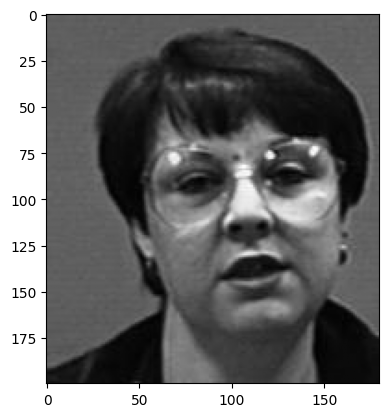

In [4]:
def show(image, m=200, n=180):
    """
    Plot the flattened grayscale 'image' of width n and height m.

    Parameters
    ----------
    image : 1D ndarray
        Flattened vector representing an image.
    m : int
        Number of rows (height) of the image.
    n : int
        Number of columns (width) of the image.

    Returns
    -------
    None
    """
    new = image.reshape((m, n))
    plt.imshow(new, cmap="gray")


images = get_faces()
show(images[:, 0])

In [5]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt


class FacialRec(object):
    """
    A class for storing a database of face images, with methods for
    matching other faces to the database.

    Attributes
    ----------
    faces : (mn, k) ndarray
        Matrix where each column is a flattened image.
    mean_face : (mn, 1) ndarray
        Mean face vector.
    shifted_faces : (mn, k) ndarray
        Mean-centered faces.
    eigen_faces : (mn, k) ndarray
        Eigenfaces (columns of U from SVD).
    """

    def __init__(self, path='./faces94.zip'):
        faces = get_faces(path)
        self.faces = faces

        self.mean_face = np.mean(faces, axis=1, keepdims=True)

        self.shifted_faces = self.faces - self.mean_face

        self.U, self.S, self.VT = la.svd(self.shifted_faces, full_matrices=False)

        self.eigen_faces = self.U

    def project(self, A, s):
        """
        Project image(s) onto first s eigenfaces.
        """
        U_s = self.U[:, :s]

        A = np.atleast_2d(A)

        A_centered = A - self.mean_face

        return U_s.T @ A_centered

    def reconstruct(self, A, s):
        """
        Reconstruct image(s) using first s eigenfaces.
        """
        U_s = self.eigen_faces[:, :s]
        coeffs = self.project(A, s)
        return U_s @ coeffs + self.mean_face

    def find_nearest(self, g, s=38):
        """
        Find closest face in database.
        """
        # Project database faces
        coeffs_db = self.project(self.faces, s)   # (s, k)

        # Project input face
        if g.ndim == 1:
            g = g.reshape(-1, 1)

        coeffs_g = self.project(g, s)             # (s, 1)

        # Compute distances
        distances = np.linalg.norm(coeffs_db - coeffs_g, axis=0)

        return np.argmin(distances)

    def match(self, image, s=38, m=200, n=180):
        """
        Display input image and its closest match.
        """
        idx = self.find_nearest(image, s)
        match_img = self.faces[:, idx]

        plt.figure(figsize=(8, 4))

        # Input image
        plt.subplot(1, 2, 1)
        plt.title("Input")
        plt.imshow(image.reshape(m, n), cmap="gray")
        plt.axis("off")

        # Matched image
        plt.subplot(1, 2, 2)
        plt.title("Match")
        plt.imshow(match_img.reshape(m, n), cmap="gray")
        plt.axis("off")

        plt.show()

## Problem 2

- In `FacialRec.__init__()`, compute $F$, the mean face $\boldsymbol{\mu}$, and the mean-shifted faces $\bar{F}$.
Store each as an attribute.

- Initialize a `FacialRec` object and display its mean face, plus an original image and its shifted face.

Text(0.5, 1.0, 'mean face')

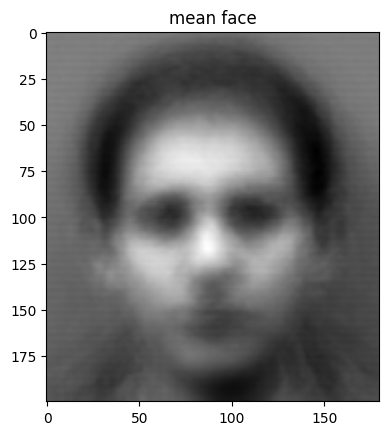

In [6]:
i = 0
facialrec = FacialRec()

show(facialrec.mean_face.flatten(), 200, 180)
plt.title("mean face")



Text(0.5, 1.0, 'the first of the images')

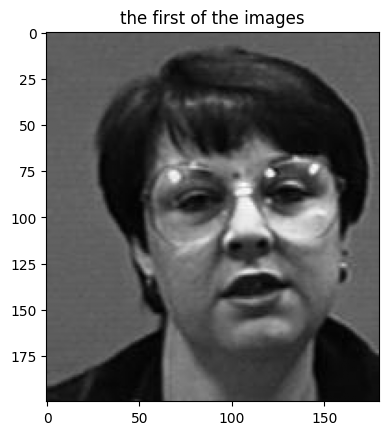

In [7]:

show(facialrec.faces[:, i], 200, 180)
plt.title("the first of the images")

Text(0.5, 1.0, 'face 1 after mean shifting')

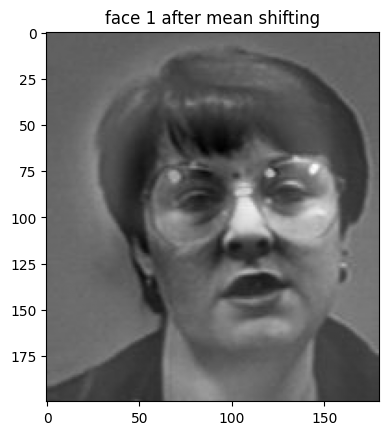

In [8]:
show(facialrec.shifted_faces[:, i], 200, 180)
plt.title("face 1 after mean shifting")

## Problem 3

- In `FacialRec.__init__()`, compute the compact SVD of $\bar{F}$ and store the $U$ as an attribute.
- Use `show()` to display some of the eigenfaces (the columns of $U$).
- Implement `FacialRec.project()` (in a single line).


Text(0.5, 1.0, 'eigen face 0 (the first)')

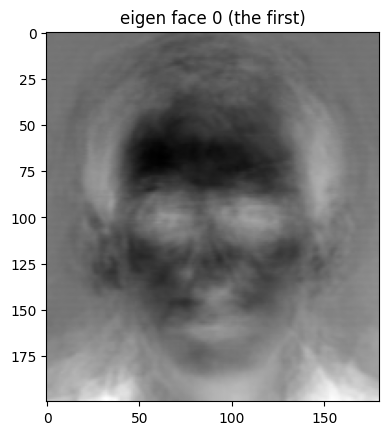

In [9]:
show(facialrec.U[:,0])
plt.title("eigen face 0 (the first)")

Text(0.5, 1.0, 'eigen face 49 (the 50th)')

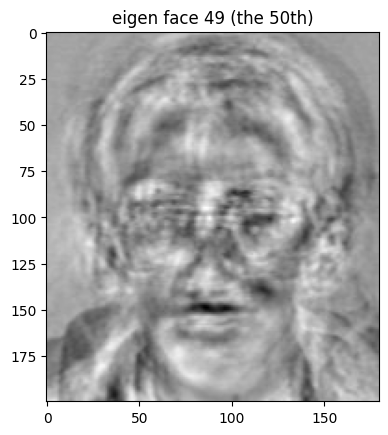

In [10]:
show(facialrec.U[:, 49])
plt.title("eigen face 49 (the 50th)")

Text(0.5, 1.0, 'eigen face 99 (the 100th)')

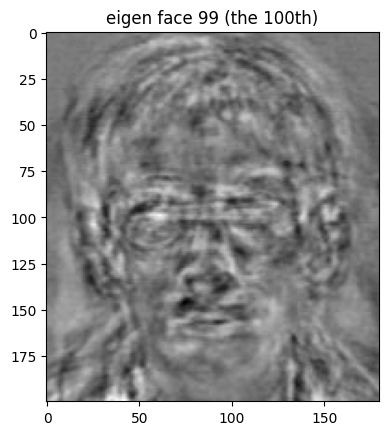

In [11]:
show(facialrec.U[:,99])
plt.title("eigen face 99 (the 100th)")

## Problem 4

- Select one of the shifted images $\bar{\mathbf{f}}_i$.
- For at least 4 values of $s$, use `FacialRec.project()` to compute the corresponding $s$-projection $\widehat{\mathbf{f}}_i$, then compute the reconstruction $\widetilde{\mathbf{f}}_i$.
- Display each of the reconstructions and the original image.

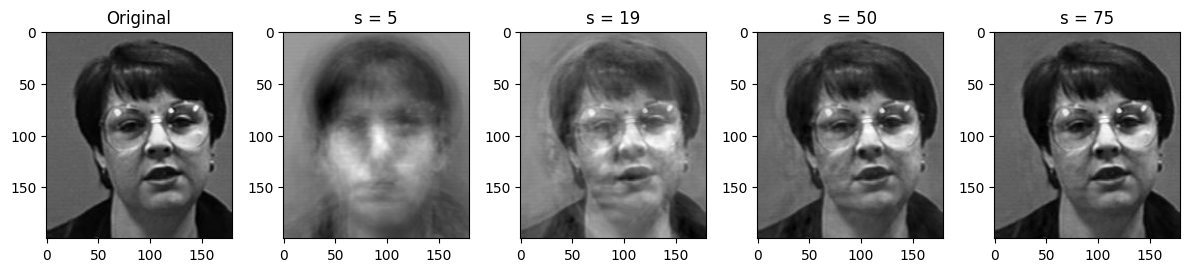

In [12]:
U = facialrec.U
mu = facialrec.mean_face
i = 0
x = facialrec.faces[:, i]

plt.figure(figsize=(12, 3))
s_values = [5, 19, 50, 75]

# original
plt.subplot(1, len(s_values) + 1, 1)
plt.title("Original")
show(x, 200, 180)

for idx, s in enumerate(s_values):
    U_s = U[:, :s]

    # projection coefficients
    coeffs = U_s.T @ (x.reshape(-1, 1) - mu)

    # reconstruction (Eqn 3)
    x_hat = U_s @ coeffs + mu

    plt.subplot(1, len(s_values) + 1, idx + 2)
    plt.title(f"s = {s}")
    show(x_hat.flatten(), 200, 180)
plt.tight_layout()
plt.show()

## Problem 5 
Implement `FacialRec.find_nearest()`.

## Problem 6

- Implement `FacialRec.match()`.
- Generate some random faces with `sample_faces()`, and use `FacialRec.match()` to find the closest match (let $s=38$).
- For each test, display the sample image and its closest match.

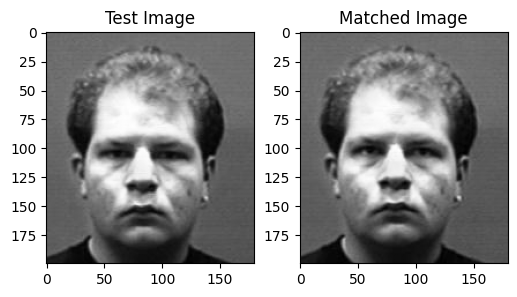

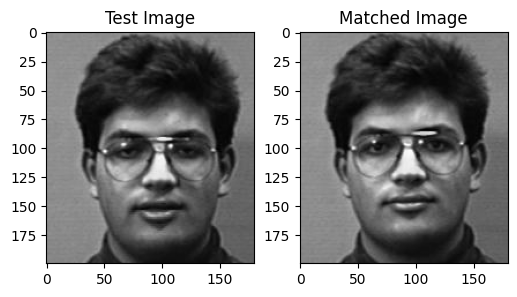

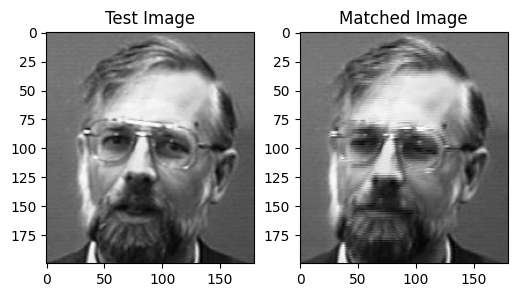

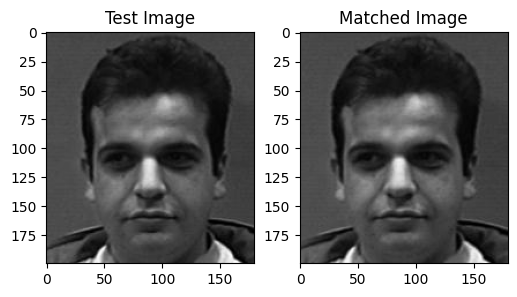

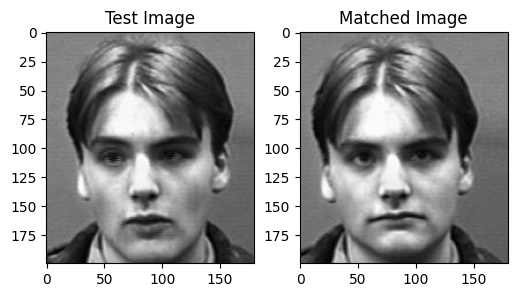

In [13]:
facialrec = FacialRec("faces94.zip")

# loop over random test faces
for test_image in sample_faces(5):

    # find best match in database
    idx = facialrec.find_nearest(test_image, s=38)

    # get matched image
    match_image = facialrec.faces[:, idx]

    # display both
    plt.figure(figsize=(6, 3))

    plt.subplot(1, 2, 1)
    plt.title("Test Image")
    show(test_image, 200, 180)
    
    plt.subplot(1, 2, 2)
    plt.title("Matched Image")
    show(match_image, 200, 180)

    plt.show()